In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
import numpy as np

def sho_expects(del_t, period_number, eta, k, gamma, x0, p0):
    w1_real = 50000 * 2 * np.pi #rad/s
    m_bead = 4.8e-18 #kg
    hbar = 1.054e-34 #J s

    # Dimensionless initial conditions
    x = x0
    p = p0

    w1_scale = w1_real
    m_scale = m_bead

    x_scale = np.sqrt(hbar/(m_scale*w1_scale))
    p_scale = np.sqrt(hbar*m_scale*w1_scale)
    t_scale = 1/w1_scale

    w1 = w1_real/w1_scale
    m = m_bead/m_scale

    epsilon = -2*gamma/w1

    T = (2*np.pi)/w1
    t = period_number*T

    steps = int(t/del_t)
    t_arr = np.linspace(0, t, steps)
    t_per_arr = t_arr/T

    alpha_x_stream = [x]
    alpha_p_stream = []

    var_x = 1/(2*m*w1)
    var_p = m*w1/2
    cov_xp = 0.0

    x_sq = var_x + x**2
    p_sq = var_p + p**2

    exp_x = [x]
    exp_p = [p]
    exp_x_sq = [x_sq]
    exp_p_sq = [p_sq]

    w_sq = w1**2*(1-2*epsilon)

    phi = np.arctan2(p, x)
    phi_p = np.pi/2 - 2*phi

    w_sq_list = [w_sq]
    phi_p_list = [phi_p]

    X_rot = x
    Y_rot = p

    phi_p_rot_list = [phi_p]

    for i in range(steps - 1):

        del_W = np.random.normal(0.0, np.sqrt(del_t))

        x += (1/m*p*del_t) + (np.sqrt(8*eta*k)*var_x*del_W) 
        p += (-m* w_sq*x*del_t) + (np.sqrt(8*eta*k)*cov_xp*del_W) 
        
        var_x += ((2/m*cov_xp) - (8*eta*k*var_x**2)) * del_t
        var_p += ((-2*m*w_sq*cov_xp) + 2*k - (8*eta*k*cov_xp**2)) * del_t
        cov_xp += (1/m*var_p - m*w_sq*var_x - (8*eta*k*var_x*cov_xp)) *del_t
        
        x_sq = var_x + x**2
        p_sq = var_p + p**2

        alpha_x = x + del_W / np.sqrt(8 * eta * k * del_t)
        alpha_x_stream.append(alpha_x)

        if i > 0:
            alpha_p = m * (alpha_x_stream[-1] - alpha_x_stream[-2]) / del_t
            alpha_p_stream.append(alpha_p)

        x_dot = (x - exp_x[-1])/del_t


        phi = np.arctan2(p, x)
        phi_p = np.pi/2 - 2*phi


        w_sq = w1**2*(1 - 2*epsilon*np.cos(2*w1*t_arr[i]))
        #w_sq = w1**2 * (1 - epsilon*x*x_dot)

        w_sq_list.append(w_sq)
        phi_p_list.append(phi_p)

        X_rot = x * np.cos(w1 * t_arr[i]) - p * np.sin(w1 * t_arr[i])
        Y_rot = x * np.sin(w1 * t_arr[i]) + p * np.cos(w1 * t_arr[i])

        phi_rot = np.arctan2(Y_rot, X_rot)
        phi_p_rot = np.pi/2 - 2*phi_rot
        phi_p_rot_list.append(phi_p_rot)

        exp_x.append(x)
        exp_p.append(p)
        exp_x_sq.append(x_sq)
        exp_p_sq.append(p_sq)

    t_real_arr = t_arr * t_scale
    exp_x_real = np.array(exp_x) * x_scale
    exp_p_real = np.array(exp_p) * p_scale
    exp_x_sq_real = np.array(exp_x_sq) * x_scale**2
    exp_p_sq_real = np.array(exp_p_sq) * p_scale**2

    #var_x_real = var_x * x_scale**2
    #var_p_real = var_p * p_scale**2
    #cov_xp_real = cov_xp * x_scale * p_scale

    alpha_x_stream_real = np.array(alpha_x_stream) * x_scale
    alpha_p_stream_real = np.array(alpha_p_stream) * p_scale

    w_sq_arr_real = np.array(w_sq_list) / t_scale**2

    return [
        t_real_arr,
        t_per_arr,
        exp_x_real,
        exp_p_real,
        alpha_x_stream_real,
        alpha_p_stream_real,
        exp_x_sq_real,
        exp_p_sq_real,
        w_sq_arr_real,
        np.array(phi_p_list),
        np.array(phi_p_rot_list),
    ]

In [36]:
t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real,exp_x_sq_real,exp_p_sq_real,w_sq_list,phi_p_list, phi_p_rot_list = sho_expects(del_t=0.0001,period_number=50, eta=1, k=0.05, gamma=0.01, x0=20, p0=20)

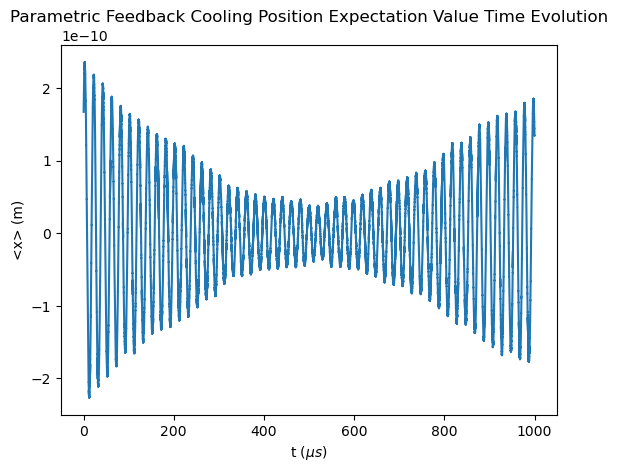

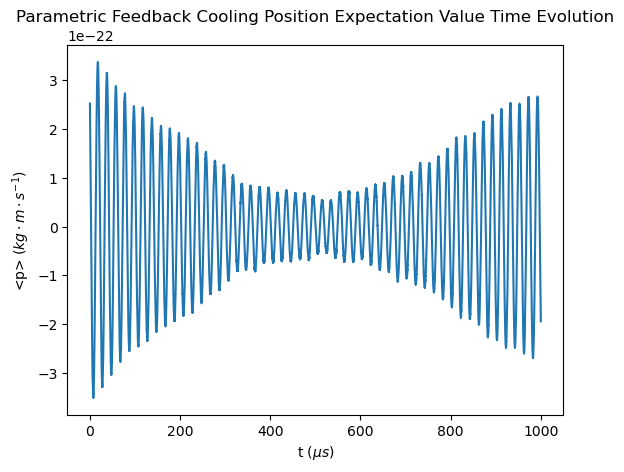

In [37]:
plt.figure()
plt.plot(t_real_arr*10**6, exp_x_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<x> (m)")
plt.title("Parametric Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, exp_p_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<p> ($kg \cdot m \cdot s^{-1}$)")
plt.title("Parametric Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

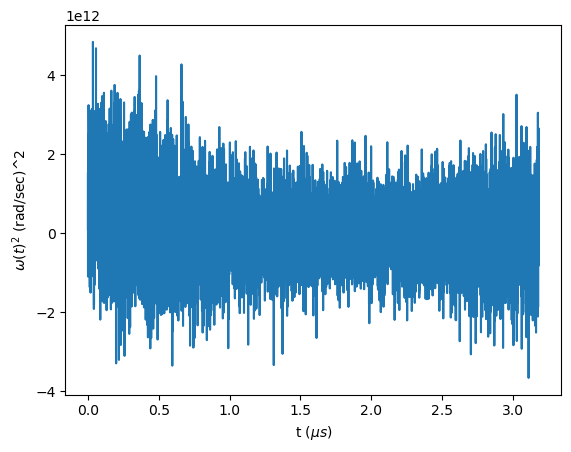

In [28]:
plt.figure()
plt.plot((t_real_arr[:10000])*10**6, np.array(w_sq_list[:10000]))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\omega(t)^2$ (rad/sec)^2")
plt.show()

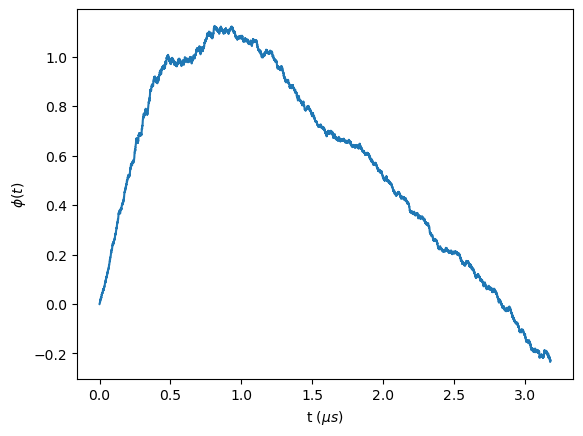

In [14]:
plt.figure()
plt.plot((t_real_arr[:10000])*10**6, np.array(phi_p_rot_list[:10000]))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\phi(t)$")
plt.show()

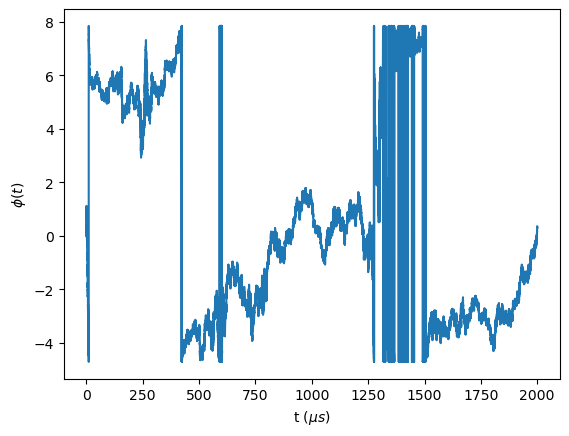

In [15]:
plt.figure()
plt.plot((t_real_arr)*10**6, np.array(phi_p_rot_list))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\phi(t)$")
plt.show()